In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tslearn.clustering import KShape
from tslearn.preprocessing import TimeSeriesScalerMeanVariance
from scipy.optimize import curve_fit

'''#Run this to regenerate the .npy files for the data
df = pd.read_parquet("data/RMDC26_Beginner_Tier_test.parquet")
print(df.columns)
print(df.shape)

event_names = [f"RMDC26_{i:06d}" for i in range(1, 189)]

# event names are from RMDC26_000001 to RMDC26_000188
# filters are ['F087', 'F146', 'F213']

def makeFliterDataMatrix(filter, df):
  res = []
  filter_name = filter
  for event_id in event_names:
    res.append(df.loc[(df["name"] == event_id) & (df["filt"] == filter_name), ["mag","mag_err","bjd"]].sort_values("bjd").to_numpy().T)
  return np.array(res)

F087 = makeFliterDataMatrix("F087", df)
print(F087.shape)
F146 = makeFliterDataMatrix("F146", df)
print(F146.shape)
F213 = makeFliterDataMatrix("F213", df)
print(F146.shape)

np.save("data/F087.npy", F087)
np.save("data/F146.npy", F146)
np.save("data/F213.npy", F213)'''

F087 = np.load("data/F087.npy")
F146 = np.load("data/F146.npy")
F213 = np.load("data/F213.npy")

F087_mags = F146[:, 0, :]   # (n_events, n_points)
bjd = F146[0, 2, :]         # shared time axis

In [42]:
# Each event's light curve is observed in 6 separate campaigns, with large
# time gaps between them. bjd is a shared grid across all events, so the
# chunk boundaries are the same for every event.

def find_chunks(time_axis, gap_threshold=10.0):
    """Split a shared time axis into contiguous observing chunks, breaking
    wherever the gap between consecutive points exceeds gap_threshold (days)."""
    gaps = np.diff(time_axis)
    break_points = np.where(gaps > gap_threshold)[0]
    starts = np.concatenate(([0], break_points + 1))
    ends = np.concatenate((break_points, [len(time_axis) - 1]))
    return list(zip(starts.tolist(), ends.tolist()))

chunks = find_chunks(bjd)
print(f"Found {len(chunks)} chunks: {chunks}")

Found 6 chunks: [(0, 7699), (7700, 15400), (15401, 23103), (23104, 30804), (30805, 38506), (38507, 46207)]


In [43]:
def find_anomalies(series, chunks, threshold=3.0, tol=5):
    """
    Find sustained-deviation anomalies in a light curve.

    The noise baseline (mean, S.D.) is computed from the whole series --
    most of it is flat noise around this baseline, and the lensing event
    shows up as a sustained deviation away from it. Each chunk is scanned
    independently so an anomaly can never span the gap between chunks --
    it always closes by the last point of the chunk it started in, instead
    of running on into (or past) the next observing campaign.

    threshold : n, number of S.D. from the baseline mean that counts as
                "above threshold".
    tol       : d, a run must exceed this many consecutive points to
                start (or end) an anomaly.

    Returns a list of (start_idx, end_idx, chunk_idx) in global index
    coordinates.
    """
    mean = series.mean()
    std = series.std()

    anomalies = []
    for c_idx, (c_start, c_end) in enumerate(chunks):
        chunk_series = series[c_start:c_end + 1]
        dev = np.abs(chunk_series - mean) > threshold * std

        above_run = 0
        below_run = 0
        in_anomaly = False
        start_idx = None

        for t, flagged in enumerate(dev):
            if flagged:
                above_run += 1
                below_run = 0
                if not in_anomaly and above_run == tol + 1:
                    in_anomaly = True
                    start_idx = t - tol
            else:
                below_run += 1
                above_run = 0
                if in_anomaly and below_run == tol + 1:
                    end_idx = t - tol
                    anomalies.append((start_idx + c_start, end_idx + c_start, c_idx))
                    in_anomaly = False
                    start_idx = None

        # Chunk ended mid-anomaly: close it at the chunk's last point.
        if in_anomaly:
            anomalies.append((start_idx + c_start, c_end, c_idx))

    return anomalies

Event 1: found 1 anomaly window(s): [(25074, 26201, 3)]


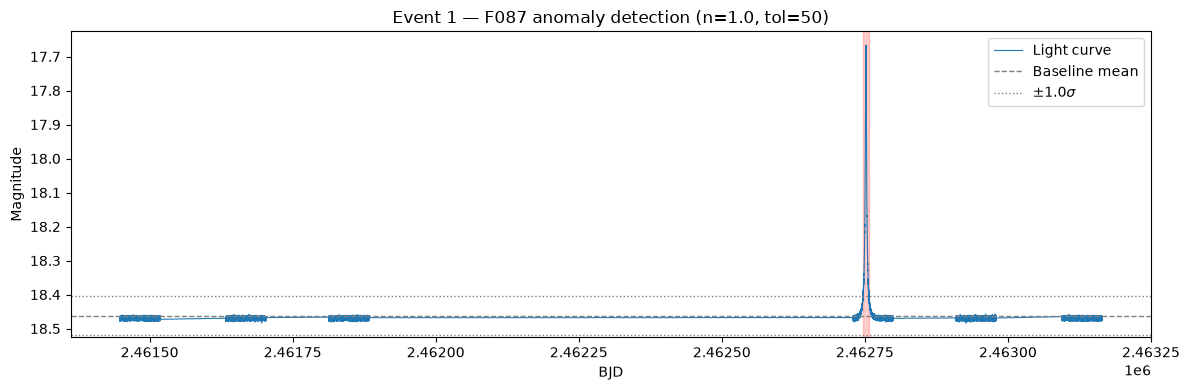

In [44]:
threshold_n = 1.0   # n S.D. from baseline
tol_d = 50            # d consecutive points

event_idx = 1
series = F087_mags[event_idx]
mean = series.mean()
std = series.std()

anomalies = find_anomalies(series, chunks, threshold=threshold_n, tol=tol_d)
print(f"Event {event_idx}: found {len(anomalies)} anomaly window(s): {anomalies}")

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(bjd, series, linewidth=0.8, label="Light curve")
ax.axhline(mean, color="gray", linestyle="--", linewidth=1, label="Baseline mean")
ax.axhline(mean + threshold_n * std, color="gray", linestyle=":", linewidth=1)
ax.axhline(mean - threshold_n * std, color="gray", linestyle=":", linewidth=1, label=f"±{threshold_n}$\\sigma$")

for start, end, _ in anomalies:
    ax.axvspan(bjd[start], bjd[end], color="red", alpha=0.2)

ax.invert_yaxis()
ax.set_xlabel("BJD")
ax.set_ylabel("Magnitude")
ax.set_title(f"Event {event_idx} — F087 anomaly detection (n={threshold_n}, tol={tol_d})")
ax.legend()
plt.tight_layout()
plt.show()

In [45]:
# Run anomaly detection across every event, and save the detected windows
# (event, index range, BJD date range, and the enclosing chunk) to a table.

records = []
for i in range(F087_mags.shape[0]):
    for (start, end, c_idx) in find_anomalies(F087_mags[i], chunks, threshold=threshold_n, tol=tol_d):
        chunk_start, chunk_end = chunks[c_idx]
        records.append({
            "event_idx": i,
            "start_idx": start,
            "end_idx": end,
            "start_bjd": bjd[start],
            "end_bjd": bjd[end],
            "n_points": end - start + 1,
            "chunk_idx": c_idx,
            "chunk_start_idx": chunk_start,
            "chunk_end_idx": chunk_end,
            "chunk_start_bjd": bjd[chunk_start],
            "chunk_end_bjd": bjd[chunk_end],
        })

anomalies_df = pd.DataFrame(records)
print(f"Found {len(anomalies_df)} anomalies across {anomalies_df['event_idx'].nunique()} events")
anomalies_df.to_csv("data/F087_anomalies.csv", index=False)
anomalies_df.head()

Found 177 anomalies across 174 events


,event_idx,start_idx,end_idx,start_bjd,end_bjd,n_points,chunk_idx,chunk_start_idx,chunk_end_idx,chunk_start_bjd,chunk_end_bjd
0,0,11425,13308,2.461667e+06,2.461684e+06,1884,1,7700,15400,2.461633e+06,2.461703e+06
1,1,25074,26201,2.462747e+06,2.462757e+06,1128,3,23104,30804,2.462729e+06,2.462799e+06
2,2,24519,30804,2.462742e+06,2.462799e+06,6286,3,23104,30804,2.462729e+06,2.462799e+06
3,3,1102,7699,2.461458e+06,2.461518e+06,6598,0,0,7699,2.461448e+06,2.461518e+06
4,4,19588,23103,2.461852e+06,2.461883e+06,3516,2,15401,23103,2.461813e+06,2.461883e+06


In [46]:
# Keep the full chunk each anomaly is in, at original resolution. Chunks are
# almost, but not exactly, the same length, so edge-pad the shorter ones up
# to the longest chunk's length.

CHUNK_LEN = max(end - start + 1 for start, end in chunks)

def pad_segment(series, start, end, length=CHUNK_LEN):
    seg = series[start:end + 1]
    pad_width = length - len(seg)
    if pad_width > 0:
        seg = np.pad(seg, (0, pad_width), mode="edge")
    return seg

anomaly_chunks = np.array([
    pad_segment(F087_mags[row.event_idx], row.chunk_start_idx, row.chunk_end_idx)
    for row in anomalies_df.itertuples()
])

# Z-normalize each chunk against its own mean/S.D.
anomaly_chunks_norm = (anomaly_chunks - anomaly_chunks.mean(axis=1, keepdims=True)) / anomaly_chunks.std(axis=1, keepdims=True)
print(anomaly_chunks_norm.shape)


(177, 7703)


In [75]:
# PSPL model and fit
def pspl_mag(t, m0, t0, tE, u0):
    u = np.sqrt(u0**2 + ((t - t0) / tE)**2)
    A = (u**2 + 2) / (u * np.sqrt(u**2 + 4))
    return m0 - 2.5 * np.log10(A)


def fit_pspl_chunk(chunk, time_axis):
    """Fit a PSPL model to one 1-D chunk and return the fitted curve and parameters."""
    m0_0 = np.median(chunk)
    t0_0 = time_axis[np.argmin(chunk)]
    tE_0 = max((time_axis[-1] - time_axis[0]) / 20.0, 1.0)
    u0_0 = 0.5

    bounds = (
        [chunk.min() - 2.0, time_axis.min(), 1e-6, 1e-6],
        [chunk.max() + 2.0, time_axis.max(), (time_axis.max() - time_axis.min()) * 10.0, 5.0],
    )
    params, _ = curve_fit(pspl_mag, time_axis, chunk, p0=[m0_0, t0_0, tE_0, u0_0],
                          bounds=bounds, maxfev=20000)
    return pspl_mag(time_axis, *params), params


# Fit every chunk and subtract the best-fit PSPL. Chunks where the fit fails
# to converge are dropped (tracked in `fit_ok`).
time_axis = np.arange(CHUNK_LEN)
pspl_models = np.full_like(anomaly_chunks_norm, np.nan)
fit_ok = np.zeros(len(anomaly_chunks_norm), dtype=bool)
for i, chunk in enumerate(anomaly_chunks_norm):
    try:
        pspl_models[i], _ = fit_pspl_chunk(chunk, time_axis)
        fit_ok[i] = True
    except (RuntimeError, ValueError):
        pass

print(f"PSPL fit succeeded for {fit_ok.sum()} / {len(fit_ok)} chunks")
anomalies_df = anomalies_df[fit_ok].reset_index(drop=True)
anomaly_chunks_norm = anomaly_chunks_norm[fit_ok]
pspl_models = pspl_models[fit_ok]
residuals = anomaly_chunks_norm - pspl_models

# Remove noise from the residuals with a sliding-window median (window in points).
MEDIAN_WINDOW = 15
# Non-overlapping windows: each window collapses to its median, so this also
# downsamples each chunk by a factor of MEDIAN_WINDOW. The last window is
# edge-padded if CHUNK_LEN isn't a multiple of MEDIAN_WINDOW.
n_bins = int(np.ceil(CHUNK_LEN / MEDIAN_WINDOW))
pad = n_bins * MEDIAN_WINDOW - CHUNK_LEN
residuals_padded = np.pad(residuals, ((0, 0), (0, pad)), mode="edge")
residuals_smooth = np.median(residuals_padded.reshape(len(residuals), n_bins, MEDIAN_WINDOW), axis=2)
bin_centers = np.arange(n_bins) * MEDIAN_WINDOW + (MEDIAN_WINDOW - 1) / 2  # x position of each median


PSPL fit succeeded for 177 / 177 chunks


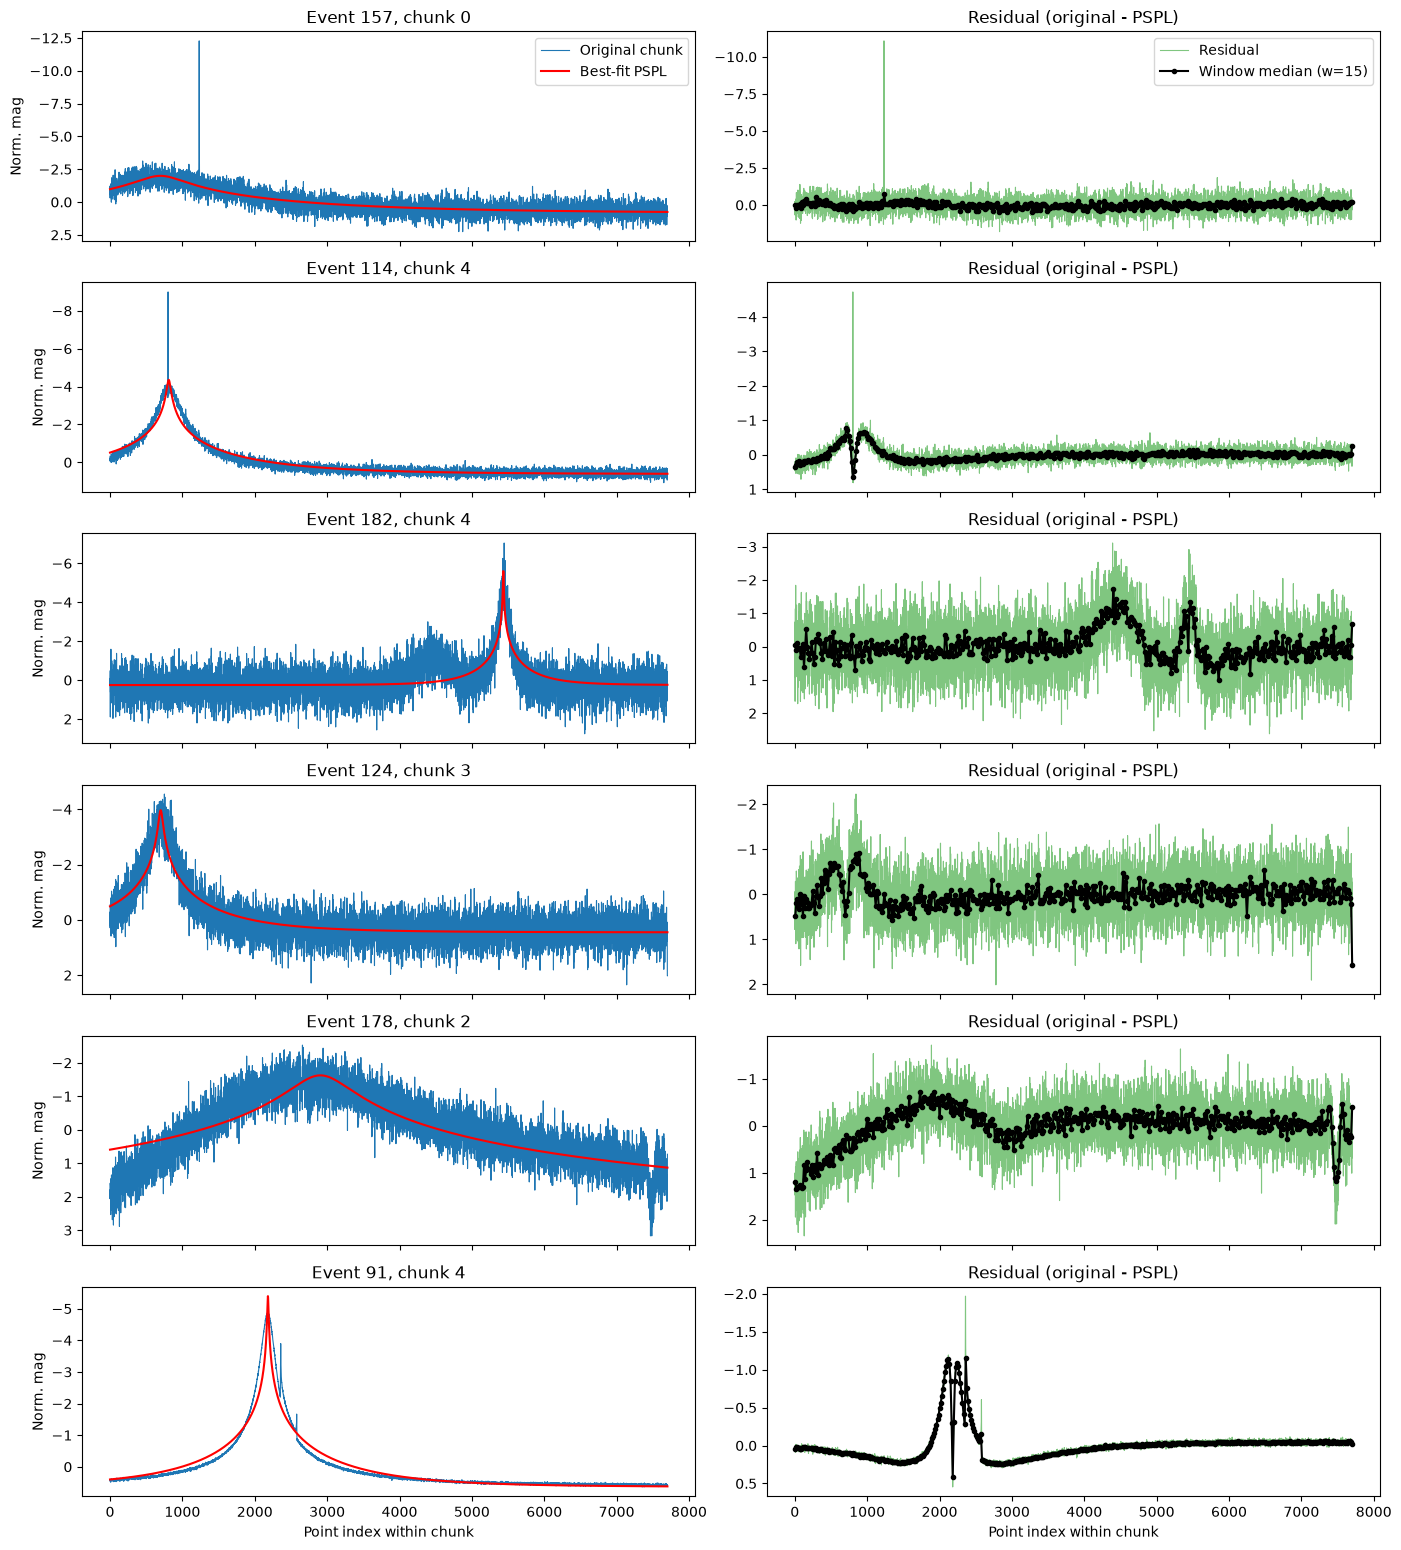

In [76]:
# A few chunks: original with the best-fit PSPL overlaid (left), and the
# residual after subtracting it (right).
n_show = 6
show_idx = np.random.choice(len(residuals), size=min(n_show, len(residuals)), replace=False)

fig, axes = plt.subplots(len(show_idx), 2, figsize=(14, 2.6 * len(show_idx)), sharex=True)
axes = np.atleast_2d(axes)
for row, i in zip(axes, show_idx):
    row[0].plot(time_axis, anomaly_chunks_norm[i], linewidth=0.8, label="Original chunk")
    row[0].plot(time_axis, pspl_models[i], color="red", linewidth=1.5, label="Best-fit PSPL")
    row[0].invert_yaxis()
    row[0].set_ylabel("Norm. mag")
    row[0].set_title(f"Event {anomalies_df.event_idx[i]}, chunk {anomalies_df.chunk_idx[i]}")
    row[1].plot(time_axis, residuals[i], linewidth=0.8, color="tab:green", alpha=0.6, label="Residual")
    row[1].plot(bin_centers, residuals_smooth[i], "o-", linewidth=1.5, markersize=3, color="k", label=f"Window median (w={MEDIAN_WINDOW})")
    row[1].invert_yaxis()
    row[1].set_title("Residual (original - PSPL)")
axes[0, 0].legend()
axes[0, 1].legend()
axes[-1, 0].set_xlabel("Point index within chunk")
axes[-1, 1].set_xlabel("Point index within chunk")
plt.tight_layout()
plt.show()


In [77]:
# K-Shape expects (n_series, length, 1) and normalized series. The window medians
# are already the downsampled series, so they go in directly.
X = TimeSeriesScalerMeanVariance().fit_transform(residuals_smooth)
print(X.shape)


(177, 514, 1)


In [81]:
n_clusters = 10

ks = KShape(n_clusters=n_clusters, random_state=0)
anomaly_labels = ks.fit_predict(X)

anomalies_df["cluster"] = anomaly_labels
print(np.bincount(anomaly_labels, minlength=n_clusters))


[15 19 28 17 16 30 14 12 21  5]


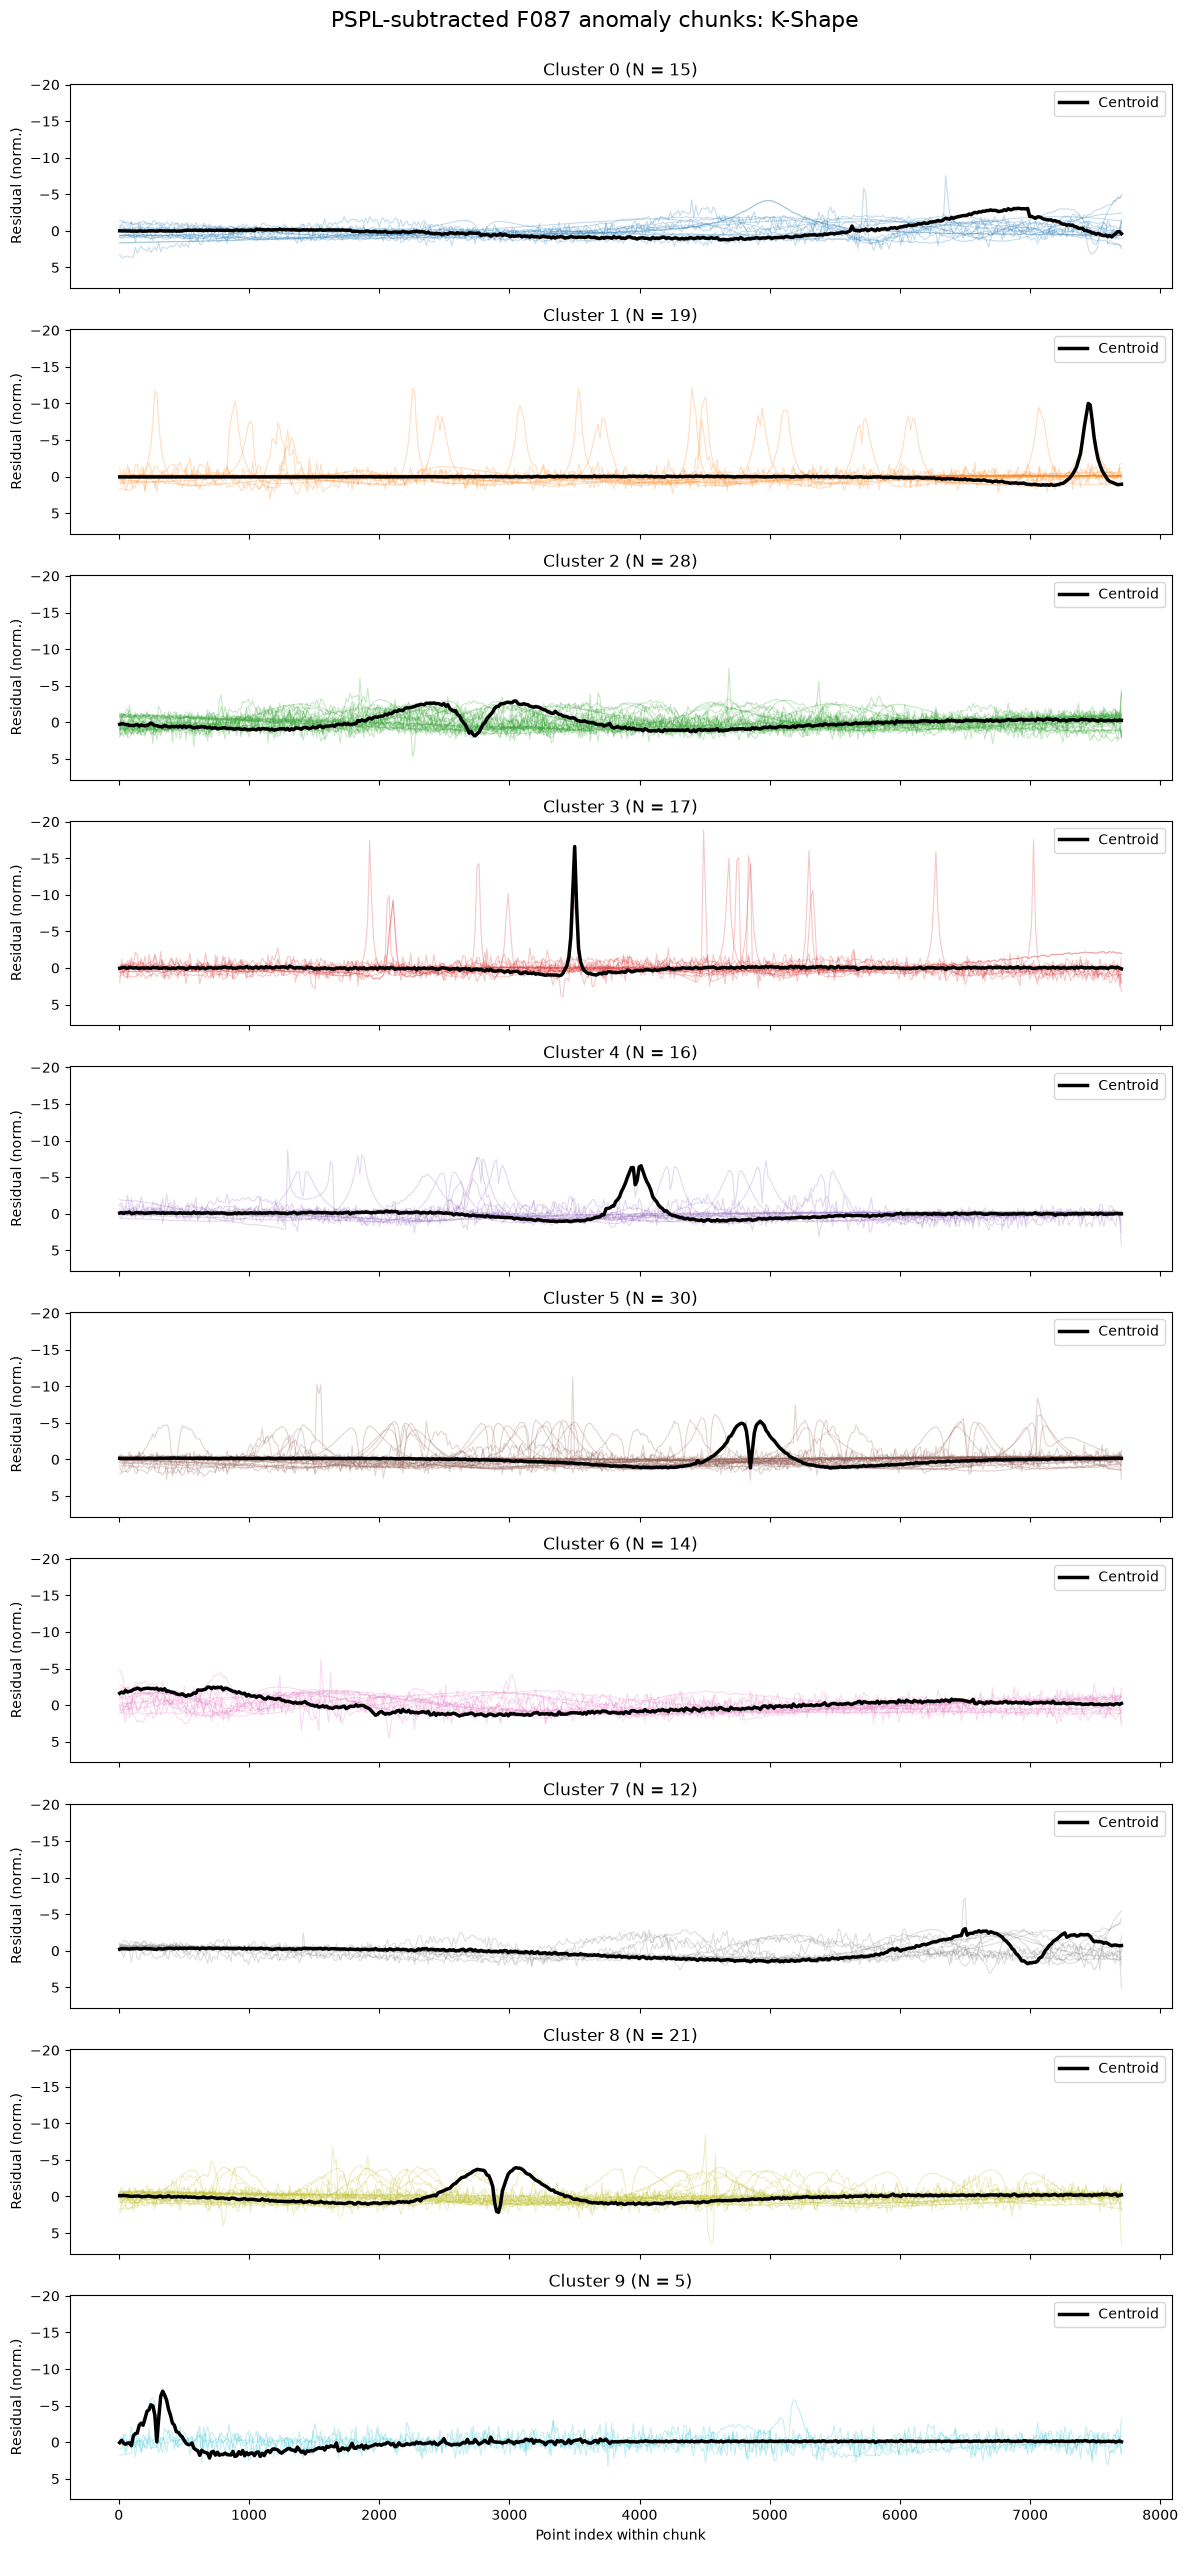

In [82]:
# Each cluster's window-median residual chunks (thin) with the K-Shape centroid (bold).
colors = plt.cm.tab10(np.arange(n_clusters))

fig, axes = plt.subplots(n_clusters, 1, figsize=(12, 2.6 * n_clusters), sharex=True, sharey=True)
for k, ax in enumerate(axes):
    m = anomaly_labels == k
    if m.any():
        ax.plot(bin_centers, X[m, :, 0].T, color=colors[k], alpha=0.25, linewidth=0.8)
    ax.plot(bin_centers, ks.cluster_centers_[k, :, 0], color="k", linewidth=2.5, label="Centroid")
    ax.set_ylabel("Residual (norm.)")
    ax.set_title(f"Cluster {k} (N = {m.sum()})")
    ax.legend(loc="upper right")
axes[0].invert_yaxis()
axes[-1].set_xlabel("Point index within chunk")

fig.suptitle("PSPL-subtracted F087 anomaly chunks: K-Shape", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()


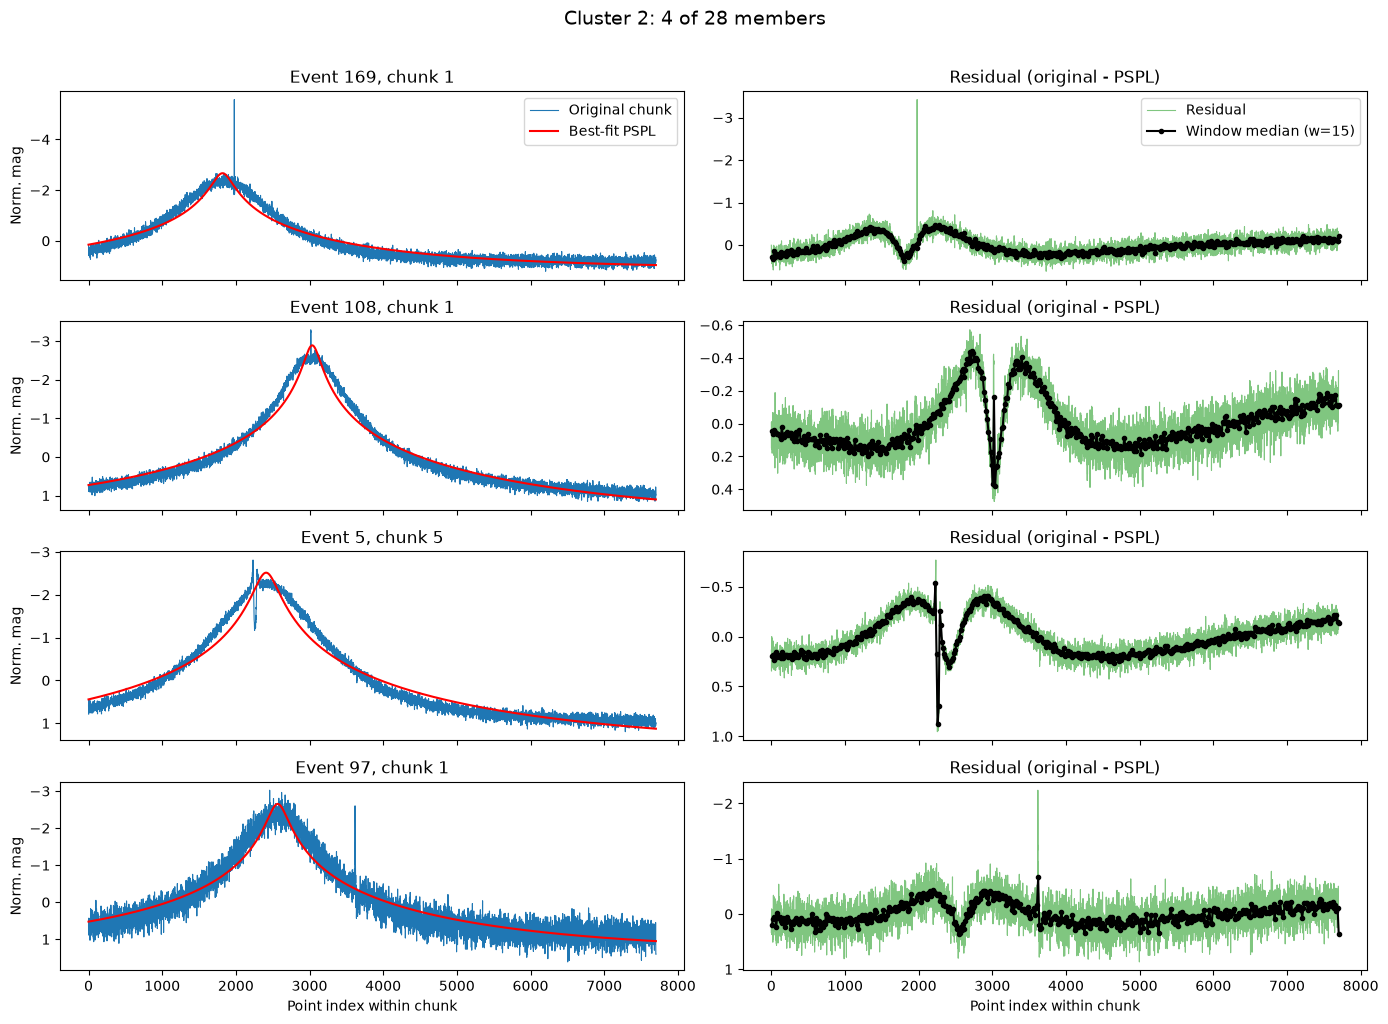

In [ ]:
# Example members of one cluster: original chunk + best-fit PSPL (left), and the
# window-median series K-Shape saw (right).
def plot_cluster_examples(cluster, n_examples=4):
    members = np.where(anomaly_labels == cluster)[0]
    if len(members) == 0:
        print(f"Cluster {cluster} is empty")
        return
    picks = np.random.choice(members, size=min(n_examples, len(members)), replace=False)

    fig, axes = plt.subplots(len(picks), 2, figsize=(14, 2.6 * len(picks)), sharex=True, squeeze=False)
    for row, i in zip(axes, picks):
        row[0].plot(time_axis, anomaly_chunks_norm[i], linewidth=0.8, label="Original chunk")
        row[0].plot(time_axis, pspl_models[i], color="red", linewidth=1.5, label="Best-fit PSPL")
        row[0].invert_yaxis()
        row[0].set_ylabel("Norm. mag")
        row[0].set_title(f"Event {anomalies_df.event_idx[i]}, chunk {anomalies_df.chunk_idx[i]}")

        row[1].plot(time_axis, residuals[i], linewidth=0.8, color="tab:green", alpha=0.6, label="Residual")
        row[1].plot(bin_centers, residuals_smooth[i], "o-", linewidth=1.5, markersize=3, color="k", label=f"Window median (w={MEDIAN_WINDOW})")
        row[1].invert_yaxis()
        row[1].set_title("Residual (original - PSPL)")
    axes[0, 0].legend()
    axes[0, 1].legend()
    axes[-1, 0].set_xlabel("Point index within chunk")
    axes[-1, 1].set_xlabel("Point index within chunk")
    fig.suptitle(f"Cluster {cluster}: {len(picks)} of {len(members)} members", fontsize=14)
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()

plot_cluster_examples(cluster=3, n_examples=4)
